For survival function (kaplan meier estimator) need 3 columns, start, end, status 
- status would say if a cotnributor is withdrawn or not

- to calculate that we have from previous studies (Bégin et al.,2017/18) using the Chebyshev theorem

- or from Humanitarian mapping research specific days (Mahmoud et al., 2022; Dittus et al., 2016) like 180

In [64]:
import pandas as pd
import duckdb 
import numpy as np
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.statistics import multivariate_logrank_test
from lifelines.statistics import pairwise_logrank_test
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
from statsmodels.stats.multitest import multipletests
from lifelines.utils import restricted_mean_survival_time
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
ohsome = pd.read_csv(r"data\input\ohsomeNow_user_timeseries.csv",delimiter =";")

In [4]:
filepath = r"data\input\ohsomeNow_user_timeseries.csv"

In [5]:
con = duckdb.connect()
con.execute(f"CREATE VIEW ob AS SELECT * FROM read_csv('{filepath}')")

#### New Contributors since 2020

In [6]:
new_users_2020 = con.sql("""
    WITH user_first_changeset AS (
        SELECT
            user_id,
            month,
            ROW_NUMBER() OVER (
                PARTITION BY user_id 
                ORDER BY month
            ) as rn
        FROM ob
    )
    SELECT
        DISTINCT user_id,
        month,
    FROM user_first_changeset
    WHERE rn = 1 AND month > '2019-12-01' 
    ORDER BY month, user_id
""").df()

In [7]:
new_users_2020

,user_id,month
0,4612,2020-01-01
1,7420,2020-01-01
2,29416,2020-01-01
3,46736,2020-01-01
4,50242,2020-01-01
...,...,...
1065481,24231874,2026-06-01
1065482,24231877,2026-06-01
1065483,24231902,2026-06-01
1065484,24231915,2026-06-01


In [8]:
total = con.sql("""
    SELECT *
    FROM ob
    WHERE user_id  IN (SELECT user_id FROM new_users_2020) 
""").df()

Adding Categories

In [9]:
categroies = con.sql("""
    SELECT user_id, 
        (n_changesets_AI == n_changesets) AS ai_only,
        (n_changesets_AI > 0 AND (n_changesets > n_changesets_AI)) AS ai_user,
        
        (n_changesets_corporate == n_changesets) AS corporate_only,
        (n_changesets_corporate > 0 AND (n_changesets > n_changesets_corporate)) AS corporate_user,
        
        (n_changesets_humanitarian == n_changesets) AS humanitarian_only,
        (n_changesets_humanitarian > 0 AND (n_changesets > n_changesets_humanitarian)) AS humanitarian_user,
        
    FROM ob
    WHERE user_id  IN (SELECT user_id FROM new_users_2020)

""").df()

In [10]:
cat_cols = ['ai_only', 'ai_user', 'corporate_only', 'corporate_user',
            'humanitarian_only', 'humanitarian_user']


##### For data since 2018

In [40]:
#trying once with data since 2018
new_users_2018 = con.sql("""
    WITH user_first_changeset AS (
        SELECT
            user_id,
            month,
            ROW_NUMBER() OVER (
                PARTITION BY user_id 
                ORDER BY month
            ) as rn
        FROM ob
    )
    SELECT
        DISTINCT user_id,
        month,
    FROM user_first_changeset
    WHERE rn = 1 AND month > '2017-12-01' 
    ORDER BY month, user_id
""").df()

In [41]:
total_18 = con.sql("""
    SELECT *
    FROM ob
    WHERE user_id  IN (SELECT user_id FROM new_users_2018) 
""").df()

In [42]:
#for data since 2018
categroies_18 = con.sql("""
    SELECT user_id, 
        (n_changesets_AI == n_changesets) AS ai_only,
        (n_changesets_AI > 0 AND (n_changesets > n_changesets_AI)) AS ai_user,
        
        (n_changesets_corporate == n_changesets) AS corporate_only,
        (n_changesets_corporate > 0 AND (n_changesets > n_changesets_corporate)) AS corporate_user,
        
        (n_changesets_humanitarian == n_changesets) AS humanitarian_only,
        (n_changesets_humanitarian > 0 AND (n_changesets > n_changesets_humanitarian)) AS humanitarian_user,
        
    FROM ob
    WHERE user_id  IN (SELECT user_id FROM new_users_2018)

""").df()

RuntimeError: Query interrupted

In [ ]:
one_category18["category"].loc[one_category18["category"]=="ai_corporate"] = "ai_user"
one_category18["category"].loc[one_category18["category"]=="ai_corporate_humanitarian"] = "ai_user"
one_category18["category"].loc[one_category18["category"]=="ai_humanitarian"] = "ai_user"


In [ ]:
long_df_18 = categroies_18.melt(id_vars='user_id', value_vars=cat_cols,
                   var_name='category', value_name='flag')
long_df_18 = long_df_18[long_df_18['flag']].drop(columns='flag')
long_df_18['base'] = long_df_18['category'].str.replace(r'_(only|user)$', '', regex=True)
one_category18 = (
    long_df_18.groupby('user_id')['base']
    .apply(lambda x: '_'.join(sorted(set(x))))
    .reset_index(name='category')
)

In [ ]:
active18 = total_18[["user_id", "month", "n_changesets"]]
active18["month"] = active18["month"].dt.to_period("M")

#### Final: Data since 2020

In [11]:
long_df = categroies.melt(id_vars='user_id', value_vars=cat_cols,
                   var_name='category', value_name='flag')

In [12]:
long_df = long_df[long_df['flag']].drop(columns='flag')

In [13]:
long_df['base'] = long_df['category'].str.replace(r'_(only|user)$', '', regex=True)


In [14]:
one_category = (
    long_df.groupby('user_id')['base']
    .apply(lambda x: '_'.join(sorted(set(x))))
    .reset_index(name='category')
)

In [ ]:
one_category.to_csv(r"data\ouput\affiliation_contributor_uid_ohsome.csv", index = False)

independent                  806794
humanitarian                 226262
corporate_humanitarian        11287
ai_humanitarian                9883
ai                             6055
corporate                      3338
ai_corporate_humanitarian      1562
ai_corporate                    305

In [ ]:
one_category["category"].loc[one_category["category"]=="ai_corporate"] = "ai_user"

In [ ]:
one_category["category"].loc[one_category["category"]=="ai_corporate_humanitarian"] = "ai_user"
one_category["category"].loc[one_category["category"]=="ai_humanitarian"] = "ai_user"

In [17]:
active = total[["user_id", "month", "n_changesets"]]

In [ ]:
active["month"] = active["month"].dt.to_period("M")

### Configuration

In [19]:
STUDY_END = pd.Period("2026-06", freq="M")   # last fully-observed month
FIXED_THRESHOLD_MONTHS = 6                    # ~180 days, for comparison
CONFIDENCE = 0.95                             # for the Chebyshev bound
MIN_ACTIVE_MONTHS_FOR_CHEBYSHEV = 3           # need >=2 gaps to estimate sigma
ONE_SIDED = True                              # Cantelli (recommended) vs classic Chebyshev

ALPHA = 1 - CONFIDENCE
if ONE_SIDED:
    K_CHEBYSHEV = np.sqrt((1 - ALPHA) / ALPHA)   # ~4.36 for 95%
else:
    K_CHEBYSHEV = np.sqrt(1 / ALPHA)             # ~4.47 for 95%

K_CHEBYSHEV

np.float64(4.358898943540671)

In [20]:
def chebyshev_threshold(gaps, k=K_CHEBYSHEV):
    """gaps: array of inter-contribution gaps (in months) for ONE user."""
    mu = gaps.mean()
    sigma = gaps.std(ddof=1)
    return mu + k * sigma

In [21]:
def build_survival_table(active_df, study_end=STUDY_END,
                          fixed_threshold=FIXED_THRESHOLD_MONTHS):
    rows = []
    for uid, g in active_df.groupby("user_id"):
        months = np.sort(g["month"].unique())
        first, last = months[0], months[-1]
        tenure = (last - first).n                  # months from first to last activity
        time_since_last = (study_end - last).n      # months of silence up to study end

        # --- fixed-threshold classification ---
        event_fixed = int(time_since_last > fixed_threshold)
        duration_fixed = tenure if event_fixed else (study_end - first).n

        # --- Chebyshev personalized classification ---
        if len(months) >= MIN_ACTIVE_MONTHS_FOR_CHEBYSHEV:
            gaps = np.diff([m.ordinal for m in months])
            threshold = chebyshev_threshold(gaps)
            event_cheb = int(time_since_last > threshold)
            duration_cheb = tenure if event_cheb else (study_end - first).n
        else:
            # not enough history for a personal mu/sigma estimate -> fill later
            threshold = np.nan
            event_cheb = np.nan
            duration_cheb = np.nan

        rows.append(dict(
            user_id=uid, n_active_months=len(months),
            first=first, last=last,
            duration_fixed=duration_fixed, event_fixed=event_fixed,
            threshold_cheb=threshold,
            duration_cheb=duration_cheb, event_cheb=event_cheb,
        ))
    return pd.DataFrame(rows)


In [22]:
def fill_missing_chebyshev(surv_df):
    """
    Users below MIN_ACTIVE_MONTHS_FOR_CHEBYSHEV can't get a personal mu/sigma.
    Fallback here: use the fixed-threshold classification for them instead.
    (Alternative: pool ALL users' gaps into one population mu/sigma and apply
    that to these users instead of the fixed threshold - swap in if preferred.)
    """
    mask = surv_df["event_cheb"].isna()
    surv_df.loc[mask, "event_cheb"] = surv_df.loc[mask, "event_fixed"]
    surv_df.loc[mask, "duration_cheb"] = surv_df.loc[mask, "duration_fixed"]
    surv_df["event_cheb"] = surv_df["event_cheb"].astype(int)
    return surv_df

In [23]:
active.dtypes

user_id             int64
month           period[M]
n_changesets        int64
dtype: object

In [24]:
surv = build_survival_table(active)

In [25]:
surv.loc[surv["event_fixed"] != surv["event_cheb"]]

,user_id,n_active_months,first,last,duration_fixed,event_fixed,threshold_cheb,duration_cheb,event_cheb
0,144,1,2025-10,2025-10,0,1,NaN,NaN,NaN
1,212,1,2026-04,2026-04,2,0,NaN,NaN,NaN
2,265,1,2023-10,2023-10,0,1,NaN,NaN,NaN
3,285,1,2021-11,2021-11,0,1,NaN,NaN,NaN
4,313,3,2021-01,2023-01,24,1,73.64414,65.0,0.0
...,...,...,...,...,...,...,...,...,...
1065481,24231874,1,2026-06,2026-06,0,0,NaN,NaN,NaN
1065482,24231877,1,2026-06,2026-06,0,0,NaN,NaN,NaN
1065483,24231902,1,2026-06,2026-06,0,0,NaN,NaN,NaN
1065484,24231915,1,2026-06,2026-06,0,0,NaN,NaN,NaN


In [26]:
surv = fill_missing_chebyshev(surv)

Adding category columns

In [27]:
surv = surv.merge(one_category, on="user_id", how="left")

In [28]:
surv[["category"]] = surv[["category"]].fillna("independent")

### Plot

In [29]:
surv["threshold_cheb"].describe()

count    148398.000000
mean         25.258984
std          30.611250
min           1.000000
25%           5.298718
50%          15.057926
75%          33.054704
max         269.665525
Name: threshold_cheb, dtype: float64

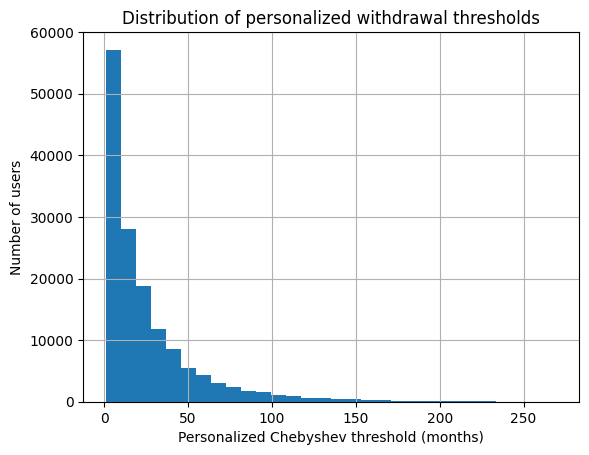

In [30]:
surv["threshold_cheb"].hist(bins=30)
plt.xlabel("Personalized Chebyshev threshold (months)")
plt.ylabel("Number of users")
plt.title("Distribution of personalized withdrawal thresholds")
plt.show()

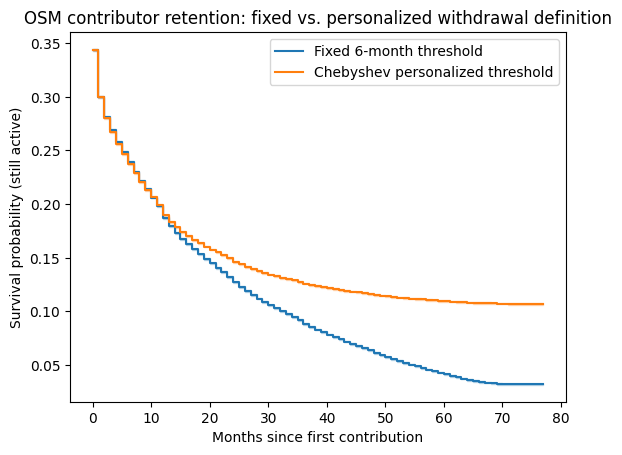

Median survival (fixed):     0.0
Median survival (Chebyshev): 0.0


In [31]:
kmf_fixed = KaplanMeierFitter(label=f"Fixed {FIXED_THRESHOLD_MONTHS}-month threshold")
kmf_fixed.fit(surv["duration_fixed"], event_observed=surv["event_fixed"])

kmf_cheb = KaplanMeierFitter(label="Chebyshev personalized threshold")
kmf_cheb.fit(surv["duration_cheb"], event_observed=surv["event_cheb"])

ax = kmf_fixed.plot_survival_function()
kmf_cheb.plot_survival_function(ax=ax)
ax.set_xlabel("Months since first contribution")
ax.set_ylabel("Survival probability (still active)")
ax.set_title("OSM contributor retention: fixed vs. personalized withdrawal definition")
plt.show()

print(f"Median survival (fixed):     {kmf_fixed.median_survival_time_}")
print(f"Median survival (Chebyshev): {kmf_cheb.median_survival_time_}")

In [32]:
non_independent = surv.loc[(surv["category"] != "independent") & (surv["category"] != "humanitarian")]

In [33]:
independent_only = surv.loc[(surv["category"] == "independent") & (surv["category"] == "humanitarian") ]

In [44]:
label_map = {
    "independent": "Independent",
    "ai": "AI only",
    "ai_user": "AI and other",
    "corporate": "Corporate Only",
    "humanitarian": "Humanitarian Only",
    "corporate_humanitarian": "Corporate and Humanitatian",
}


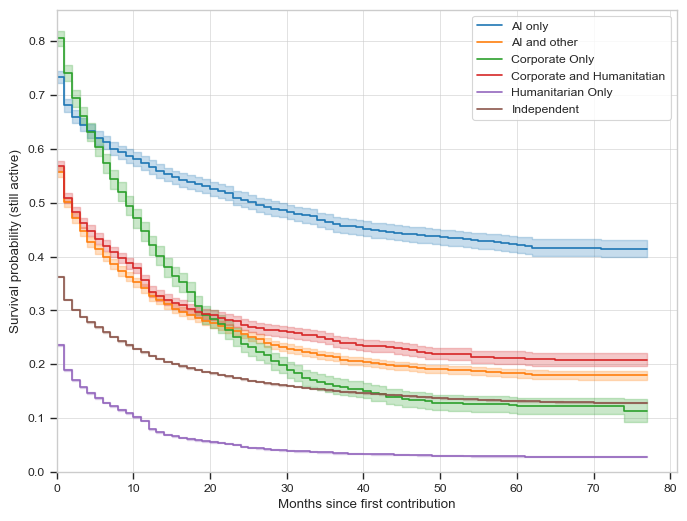

In [51]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper")

fig, ax = plt.subplots(figsize=(8,6))

for group, g in surv.groupby("category"):
    kmf = KaplanMeierFitter(label=label_map.get(group, str(group)))
    kmf.fit(g["duration_cheb"], event_observed=g["event_cheb"])
    kmf.plot_survival_function(ax=ax)

ax.set_xlabel("Months since first contribution")
ax.set_ylabel("Survival probability (still active)")
#ax.set_title("Kaplan Meier Survival with Chebyshev-defined withdrawal")
ax.grid(which='major', linewidth=0.4)
ax.grid(which='minor', linewidth=0.2)
ax.set_ylim(0,)
ax.set_xlim(0,)
ax.legend(frameon=True, facecolor="w")
fig.savefig("../../results/statistical_evaluation/Survival_cheby_v2.png", bbox_inches="tight", dpi=300)

plt.show()

### multivariate logrank test + value counts + one-off rate + Restricted survival time

In [58]:
# statistical test across all groups at once (works for 2+ groups)
result = multivariate_logrank_test(
    surv["duration_cheb"], surv["category"], surv["event_cheb"]
)
result.print_summary()

##### Fixed time interval

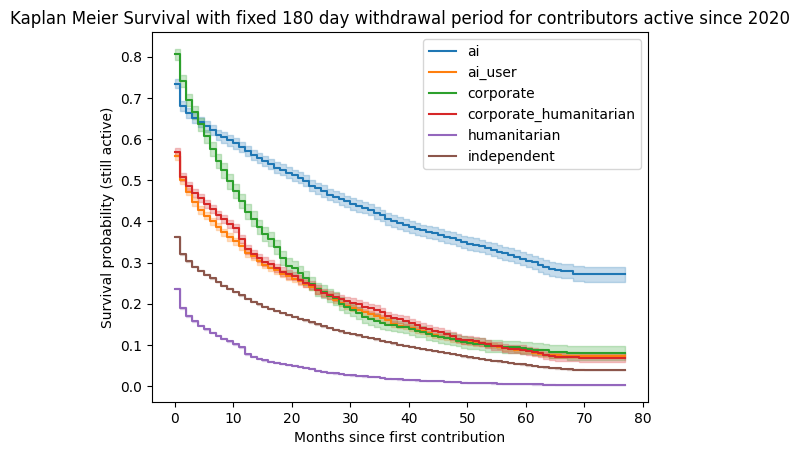

In [59]:
fig, ax = plt.subplots()

for group, g in surv.groupby("category"):
    kmf = KaplanMeierFitter(label=str(group))
    kmf.fit(g["duration_fixed"], event_observed=g["event_fixed"])
    kmf.plot_survival_function(ax=ax)

ax.set_xlabel("Months since first contribution")
ax.set_ylabel("Survival probability (still active)")
ax.set_title("Kaplan Meier Survival with fixed 180 day withdrawal period for contributors active since 2020")

#fig.savefig("../../results/statistical_evaluation/Survival_r1_fixed_180.png", bbox_inches="tight")

plt.show()

# statistical test across all groups at once (works for 2+ groups)
result = multivariate_logrank_test(
    surv["duration_cheb"], surv["category"], surv["event_cheb"]
)
result.print_summary()

In [74]:
result = logrank_test(
    surv["duration_fixed"], surv["duration_cheb"],
    event_observed_A=surv["event_fixed"],
    event_observed_B=surv["event_cheb"],
)
result.print_summary()

##### Extra: since 2018

In [37]:
surv18 = build_survival_table(active18)

In [40]:
surv18 = fill_missing_chebyshev(surv18)

In [43]:
surv18 = surv18.merge(one_category18, on="user_id", how="left")
surv18[["category"]] = surv18[["category"]].fillna("independent")

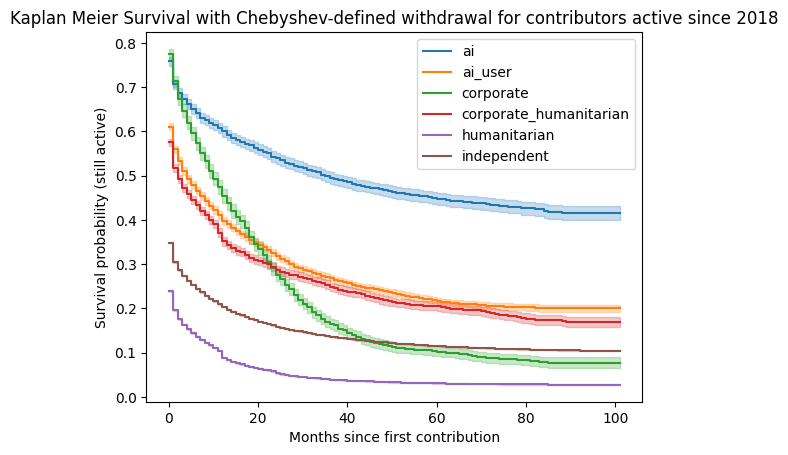

In [50]:
from lifelines.statistics import multivariate_logrank_test

fig, ax = plt.subplots()

for group, g in surv18.groupby("category"):
    kmf = KaplanMeierFitter(label=str(group))
    kmf.fit(g["duration_cheb"], event_observed=g["event_cheb"])
    kmf.plot_survival_function(ax=ax)

ax.set_xlabel("Months since first contribution")
ax.set_ylabel("Survival probability (still active)")
ax.set_title("Kaplan Meier Survival with Chebyshev-defined withdrawal for contributors active since 2018")

#fig.savefig("../../results/statistical_evaluation/Survival_r1_cheby_18.png", bbox_inches="tight")

plt.show()

# statistical test across all groups at once (works for 2+ groups)
result = multivariate_logrank_test(
    surv["duration_cheb"], surv["category"], surv["event_cheb"]
)
result.print_summary()

In [ ]:
one_off_rate = surv.groupby("category").apply(
    lambda g: (g["n_active_months"] == 1).mean()
)
one_off_rate.sort_values()

In [61]:
surv["category"].value_counts()

category
independent               806794
humanitarian              226262
ai_user                    11750
corporate_humanitarian     11287
ai                          6055
corporate                   3338
Name: count, dtype: int64

In [54]:
surv.to_csv(r"C:\Users\Lilly\Documents\Master\S4_Thesis\code_repo\data\ouput\statistical_analysis\survival_cheby_v1.csv")

In [63]:
tau = 60  # e.g. compare retention over a fixed 60-month horizon, so all groups are compared fairly
rmst = {}
for cat, g in surv.groupby("category"):
    kmf = KaplanMeierFitter().fit(g["duration_cheb"], g["event_cheb"])
    rmst[cat] = restricted_mean_survival_time(kmf, t=tau)

pd.Series(rmst).sort_values()

humanitarian               3.685358
independent               10.862979
ai_user                   15.997867
corporate                 16.754358
corporate_humanitarian    17.417631
ai                        30.366701
dtype: float64

### Pairwise logrank test

In [61]:
pairwise_results = pairwise_logrank_test(surv["duration_cheb"], surv["category"], surv["event_cheb"])
pairwise_results.summary  # p-values per pair

test_statistic              p  \
ai                     ai_user                    1082.179067  2.467126e-237   
                       corporate                   426.132940   1.128657e-94   
                       corporate_humanitarian      793.658170  1.290910e-174   
                       humanitarian               8283.536359   0.000000e+00   
                       independent                3091.008468   0.000000e+00   
ai_user                corporate                    34.749293   3.750149e-09   
                       corporate_humanitarian       13.649046   2.203533e-04   
                       humanitarian               5856.212744   0.000000e+00   
                       independent                 659.727744  1.712152e-145   
corporate              corporate_humanitarian       26.573709   2.536724e-07   
                       humanitarian               2342.198159   0.000000e+00   
                       independent                 426.341172   1.016809e-94   
corporate_humanitarian humanitarian               5932.670323   0.000000e+00   
                       independent                1162.697350  7.803912e-255   
humanitarian           independent               26272.203254   0.000000e+00   

                                                 -log2(p)  
ai                     ai_user                 785.994127  
                       corporate               312.086633  
                       corporate_humanitarian  577.647100  
                       humanitarian                   inf  
                       independent                    inf  
ai_user                corporate                27.990405  
                       corporate_humanitarian   12.147894  
                       humanitarian                   inf  
                       independent             480.903763  
corporate              corporate_humanitarian   21.910530  
                       humanitarian                   inf  
                       independent             312.237192  
corporate_humanitarian humanitarian                   inf  
                       independent             844.127467  
humanitarian           independent                    inf

In [65]:

summary = pairwise_results.summary.copy()

n_comparisons = len(summary)
print(f"Number of pairwise comparisons: {n_comparisons}")

reject, p_corrected, _, _ = multipletests(summary["p"], alpha=0.05, method="bonferroni")

summary["p_bonferroni"] = p_corrected
summary["significant_bonferroni"] = reject

summary.sort_values("p_bonferroni")

Number of pairwise comparisons: 15


test_statistic              p  \
ai                     humanitarian               8283.536359   0.000000e+00   
                       independent                3091.008468   0.000000e+00   
ai_user                humanitarian               5856.212744   0.000000e+00   
corporate              humanitarian               2342.198159   0.000000e+00   
corporate_humanitarian humanitarian               5932.670323   0.000000e+00   
humanitarian           independent               26272.203254   0.000000e+00   
corporate_humanitarian independent                1162.697350  7.803912e-255   
ai                     ai_user                    1082.179067  2.467126e-237   
                       corporate_humanitarian      793.658170  1.290910e-174   
ai_user                independent                 659.727744  1.712152e-145   
corporate              independent                 426.341172   1.016809e-94   
ai                     corporate                   426.132940   1.128657e-94   
ai_user                corporate                    34.749293   3.750149e-09   
corporate              corporate_humanitarian       26.573709   2.536724e-07   
ai_user                corporate_humanitarian       13.649046   2.203533e-04   

                                                 -log2(p)   p_bonferroni  \
ai                     humanitarian                   inf   0.000000e+00   
                       independent                    inf   0.000000e+00   
ai_user                humanitarian                   inf   0.000000e+00   
corporate              humanitarian                   inf   0.000000e+00   
corporate_humanitarian humanitarian                   inf   0.000000e+00   
humanitarian           independent                    inf   0.000000e+00   
corporate_humanitarian independent             844.127467  1.170587e-253   
ai                     ai_user                 785.994127  3.700690e-236   
                       corporate_humanitarian  577.647100  1.936365e-173   
ai_user                independent             480.903763  2.568229e-144   
corporate              independent             312.237192   1.525214e-93   
ai                     corporate               312.086633   1.692986e-93   
ai_user                corporate                27.990405   5.625223e-08   
corporate              corporate_humanitarian   21.910530   3.805086e-06   
ai_user                corporate_humanitarian   12.147894   3.305299e-03   

                                               significant_bonferroni  
ai                     humanitarian                              True  
                       independent                               True  
ai_user                humanitarian                              True  
corporate              humanitarian                              True  
corporate_humanitarian humanitarian                              True  
humanitarian           independent                               True  
corporate_humanitarian independent                               True  
ai                     ai_user                                   True  
                       corporate_humanitarian                    True  
ai_user                independent                               True  
corporate              independent                               True  
ai                     corporate                                 True  
ai_user                corporate                                 True  
corporate              corporate_humanitarian                    True  
ai_user                corporate_humanitarian                    True

### Cox Proportional Hazard

In [55]:
surv["is_ai"] = surv["category"].str.contains("ai").astype(int)
surv["is_corporate"] = surv["category"].str.contains("corporate").astype(int)
surv["is_humanitarian"] = surv["category"].str.contains("humanitarian").astype(int)

cph = CoxPHFitter()
cph.fit(
    surv[["duration_cheb", "event_cheb", "is_ai", "is_corporate", "is_humanitarian"]],
    duration_col="duration_cheb", event_col="event_cheb"
)
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 1.06549e+06 total observations, 191625 right-censored observations>
             duration col = 'duration_cheb'
                event col = 'event_cheb'
      baseline estimation = breslow
   number of observations = 1.06549e+06
number of events observed = 873861
   partial log-likelihood = -11497097.18
         time fit was run = 2026-08-22 11:42:15 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
is_ai           -0.53      0.59      0.01           -0.55           -0.52                0.58                0.60
is_corporate    -0.74      0.47      0.01           -0.76           -0.72                0.47                0.48
is_humanitarian  0.37      1.45      0.00            0.37            0.38                1.45                1.46

                 cmp to      z      p  -log2(p)
covariate                                      
is_ai              0.00 -58.73 <0.005       inf
is_corporate       0.00 -72.82 <0.005       inf
is_humanitarian    0.00 149.70 <0.005       inf
---
Concordance = 0.56
Partial AIC = 22994200.36
log-likelihood ratio test = 29836.12 on 3 df
-log2(p) of ll-ratio test = inf

| Predictor    |   HR | Meaning                                                   |
| ------------ | ---: | --------------------------------------------------------- |
| AI           | 0.59 | lower hazard independent of corporate/humanitarian status |
| Corporate    | 0.47 | lower hazard independent of AI/humanitarian status        |
| Humanitarian | 1.45 | higher hazard independent of AI/corporate status          |


In [ ]:
#could potentially be faster
surv_cph = surv[
    [
    "duration_cheb",
        "event_cheb",
        "is_ai",
        "is_corporate",
        "is_humanitarian"
    ]
].copy()

In [63]:
sample = surv_cph.sample(30000, random_state=1).copy()

cph_sample = CoxPHFitter()
cph_sample.fit(sample, duration_col="duration_cheb", event_col="event_cheb")

results = proportional_hazard_test(cph_sample, sample, time_transform="rank")
results.print_summary()

### Testing for time (extra)

In [67]:
CUTOFF = 12  # months — pick based on where your KM curves visibly diverge/cross

# --- early window: 0–12 months ---
early = surv_cph.copy()
early["duration_early"] = np.minimum(early["duration_cheb"], CUTOFF)
early["event_early"] = np.where(early["duration_cheb"] <= CUTOFF, early["event_cheb"], 0)

cph_early = CoxPHFitter()
cph_early.fit(
    early[["duration_early", "event_early", "is_ai", "is_corporate", "is_humanitarian"]],
    duration_col="duration_early", event_col="event_early"
)
print("0–12 months:")
cph_early.print_summary()

# --- late window: 12+ months, left-truncated at 12 ---
late = surv_cph[surv_cph["duration_cheb"] > CUTOFF].copy()
late["entry"] = CUTOFF

cph_late = CoxPHFitter()
cph_late.fit(
    late[["duration_cheb", "event_cheb", "is_ai", "is_corporate", "is_humanitarian", "entry"]],
    duration_col="duration_cheb", event_col="event_cheb", entry_col="entry"
)
print("12+ months:")
cph_late.print_summary()

0–12 months:


<lifelines.CoxPHFitter: fitted with 1.06549e+06 total observations, 233618 right-censored observations>
             duration col = 'duration_early'
                event col = 'event_early'
      baseline estimation = breslow
   number of observations = 1.06549e+06
number of events observed = 831868
   partial log-likelihood = -11023544.75
         time fit was run = 2026-08-22 13:25:05 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
is_ai           -0.59      0.55      0.01           -0.61           -0.57                0.54                0.57
is_corporate    -0.81      0.45      0.01           -0.83           -0.79                0.44                0.46
is_humanitarian  0.36      1.43      0.00            0.36            0.37                1.43                1.44

                 cmp to      z      p  -log2(p)
covariate                                      
is_ai              0.00 -59.65 <0.005       inf
is_corporate       0.00 -74.12 <0.005       inf
is_humanitarian    0.00 141.65 <0.005       inf
---
Concordance = 0.56
Partial AIC = 22047095.50
log-likelihood ratio test = 28368.97 on 3 df
-log2(p) of ll-ratio test = inf

12+ months:


<lifelines.CoxPHFitter: fitted with 121079 total observations, 79086 right-censored observations>
             duration col = 'duration_cheb'
                event col = 'event_cheb'
                entry col = 'entry'
      baseline estimation = breslow
   number of observations = 121079
number of events observed = 41993
   partial log-likelihood = -472810.69
         time fit was run = 2026-08-22 13:27:37 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
is_ai           -0.12      0.89      0.02           -0.16           -0.07                0.85                0.93
is_corporate    -0.20      0.82      0.03           -0.26           -0.14                0.77                0.87
is_humanitarian  0.71      2.03      0.01            0.68            0.73                1.98                2.08

                 cmp to     z      p  -log2(p)
covariate                                     
is_ai              0.00 -4.94 <0.005     20.30
is_corporate       0.00 -6.71 <0.005     35.57
is_humanitarian    0.00 56.61 <0.005       inf
---
Concordance = 0.55
Partial AIC = 945627.37
log-likelihood ratio test = 2950.65 on 3 df
-log2(p) of ll-ratio test = inf

#### too big to run complete

In [ ]:
cph_sample.check_assumptions(sample, p_value_threshold=0.05, show_plots=True)


   Bootstrapping lowess lines. May take a moment...



In [60]:
surv_cph = surv[
    [
    "duration_cheb",
        "event_cheb",
        "is_ai",
        "is_corporate",
        "is_humanitarian"
    ]
].copy()

#could potentially be faster
results = proportional_hazard_test(cph, surv_cph, time_transform="rank")
results.print_summary()

KeyboardInterrupt: 

In [57]:
cph.check_assumptions(surv_cph, p_value_threshold=0.05, show_plots=True)

KeyboardInterrupt: 